In [1]:
%cd ..
# !curl -L -o .\data\sprites.zip https://www.kaggle.com/api/v1/datasets/download/ebrahimelgazar/pixel-art
# !Expand-Archive -LiteralPath '.\data\sprites.zip'

/Users/daanwichmann/PycharmProjects/BSc Thesis


## Importing dependencies

In [2]:
import os
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms
from project.models import EDMEvelynn
from project.util.data import Sprites

In [3]:
device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

Using: mps


## Setting hyperparameters

In [4]:
DATA = os.path.join("data", "sprites")
CHECKPOINT = os.path.join("checkpoints", "sprites-edm2-class-0.pth")

In [5]:
MODEL = "edm2"

In [6]:
TARGET = 0
BATCH_SIZE = 64
RESOLUTION = 16
IN_CHANNELS = 3
OUT_CHANNELS = 3
START_CHANNELS = 64
NUM_RES_BLOCKS = 2
CHANNEL_MULTIPLIERS = (1, 2,)
ATTENTION_RESOLUTIONS = (8,)
LR = 2e-3
DROPOUT = 0.13

## Preparing dataset & dataloader

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
])

In [8]:
data = Sprites(
    images=os.path.join(DATA, "sprites.npy"),
    transform=transform,
)
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)

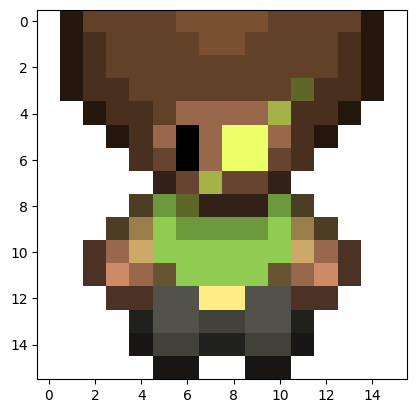

In [9]:
image = ((data[2] + 1) / 2).permute(1, 2, 0)

plt.imshow(image)
plt.show()

## Setting up the model

In [10]:
model = EDMEvelynn(
    img_resolution=RESOLUTION,
    img_channels=IN_CHANNELS,
    start_channels=START_CHANNELS,
    channel_mult=CHANNEL_MULTIPLIERS,
    num_blocks=NUM_RES_BLOCKS,
    attention_resolutions=ATTENTION_RESOLUTIONS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    lr=LR,
    network="edm2"
).to(device)

In [11]:
if os.path.exists(CHECKPOINT):
    model.load_checkpoint(CHECKPOINT)
    print("Loaded checkpoint!")

Loaded checkpoint!


## Training the model

In [12]:
# model.train(50, loader)

In [13]:
model.save_checkpoint(CHECKPOINT)

## Inspecting the results

"Looking if our model did Pookie" - Me 1 year ago about my GAN

In [14]:
x = model.heun_sampler(16).to("cpu")
x = (x + 1) / 2

100%|██████████| 32/32 [00:01<00:00, 26.72it/s]


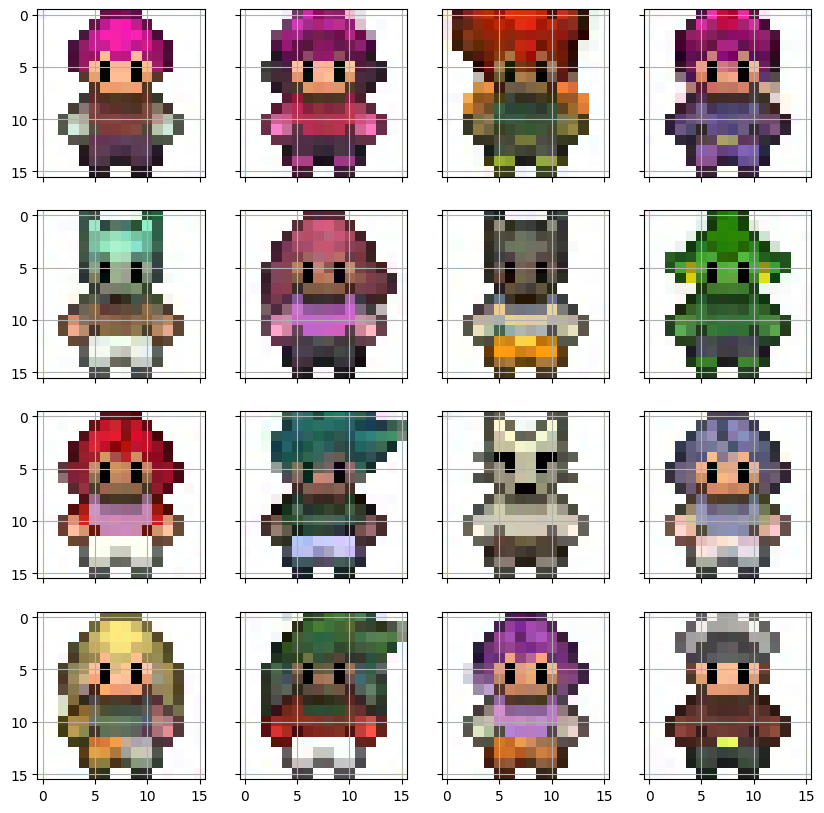

In [15]:
fig, axis = plt.subplots(4, 4, figsize=(10, 10), sharex=True, sharey=True)
for i in range(4):
    for j in range(4):
        axis[i, j].imshow(x[i * 4 + j].permute(1, 2, 0).clip(0, 1))
        axis[i, j].grid(None)